# Lab 3.2 Outlier Identification using IQR Method

Name: Anas Kabir

Course: Machine Learning

Performed in: Jupyter Notebook (Anaconda)

Objective:
To identify and handle outliers in AEP load data using Interquartile Range (IQR) technique.

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt


print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = {
    "Day":[1,2,3,4,5,6,7,8,9,10],

    "AEP_Load":[
        12000,
        12150,
        11950,
        12200,
        50000,
        11800,
        12300,
        12100,
        11900,
        3000
    ]
}


df = pd.DataFrame(data)


df

,Day,AEP_Load
0,1,12000
1,2,12150
2,3,11950
3,4,12200
4,5,50000
5,6,11800
6,7,12300
7,8,12100
8,9,11900
9,10,3000


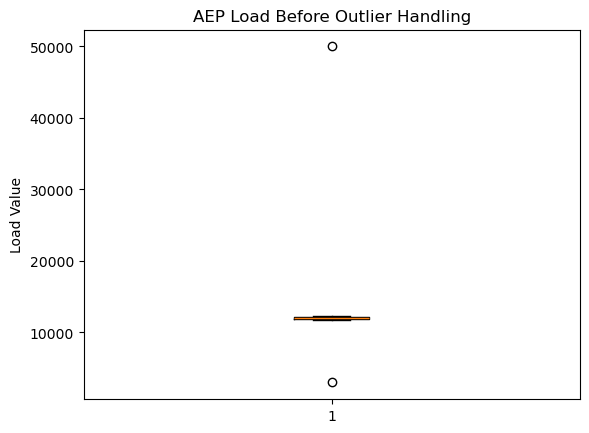

In [3]:
plt.boxplot(
    df["AEP_Load"]
)


plt.title("AEP Load Before Outlier Handling")


plt.ylabel("Load Value")


plt.show()

In [4]:
Q1 = df["AEP_Load"].quantile(0.25)

Q3 = df["AEP_Load"].quantile(0.75)


IQR = Q3 - Q1


print("Q1 Value:", Q1)

print("Q3 Value:", Q3)

print("IQR Value:", IQR)

Q1 Value: 11912.5
Q3 Value: 12187.5
IQR Value: 275.0


In [5]:
lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR


print("Lower Limit:", lower_limit)

print("Upper Limit:", upper_limit)

Lower Limit: 11500.0
Upper Limit: 12600.0


In [6]:
median_value = df["AEP_Load"].median()


df["AEP_Load"] = np.where(
    (df["AEP_Load"] < lower_limit) |
    (df["AEP_Load"] > upper_limit),
    median_value,
    df["AEP_Load"]
)


print("Outliers replaced successfully")


df

Outliers replaced successfully


,Day,AEP_Load
0,1,12000.0
1,2,12150.0
2,3,11950.0
3,4,12200.0
4,5,12050.0
5,6,11800.0
6,7,12300.0
7,8,12100.0
8,9,11900.0
9,10,12050.0


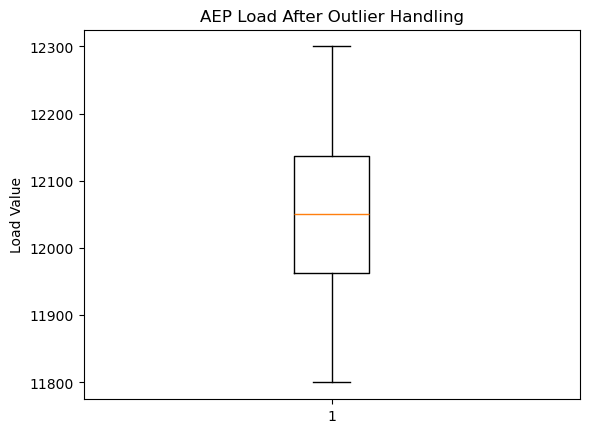

In [7]:
plt.boxplot(
    df["AEP_Load"]
)


plt.title("AEP Load After Outlier Handling")


plt.ylabel("Load Value")


plt.show()

In [8]:
df.to_csv(
    "AEP_outlier_cleaned.csv",
    index=False
)


print("Outlier cleaned dataset saved successfully")

Outlier cleaned dataset saved successfully


In [9]:
clean_data = pd.read_csv(
    "AEP_outlier_cleaned.csv"
)


clean_data

,Day,AEP_Load
0,1,12000.0
1,2,12150.0
2,3,11950.0
3,4,12200.0
4,5,12050.0
5,6,11800.0
6,7,12300.0
7,8,12100.0
8,9,11900.0
9,10,12050.0


## Conclusion

In this lab, outliers in AEP load data were detected and handled using the IQR method.

First quartile (Q1), third quartile (Q3), and Interquartile Range (IQR) values were calculated.

Lower and upper limits were used to identify abnormal values.

The detected outliers were replaced using the median value.

After preprocessing, the cleaned dataset was saved for future machine learning tasks.